<a href="https://colab.research.google.com/github/ronakkhatwani250607-cpu/anant_payload/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Soil Classification CNN
## Modified: 4-Band Input reshaped as 2×2 Band Matrix

### Pipeline overview
```
(N, 128, 128, 3)     ← original RGB
       ↓  add redundant 4th band (Red channel copy)
(N, 128, 128, 4)     ← 4 bands stacked flat
       ↓  reshape band axis: 4 → (2, 2)
(N, 128, 128, 2, 2)  ← 4 bands arranged as a 2×2 matrix per pixel
       ↓  Conv3D learns joint spatial-spectral features
```

Band layout after reshape:
```
┌───┬────┐
│ R │ G  │
├───┼────┤
│ B │ R* │   (* = redundant Red band)
└───┴────┘
```

In [64]:
!pip install tensorflow
!pip install kagglehub

In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling3D,
    Conv3D, BatchNormalization, MaxPooling3D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import kagglehub

path = kagglehub.dataset_download("ai4a-lab/comprehensive-soil-classification-datasets")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'comprehensive-soil-classification-datasets' dataset.
Path to dataset files: /kaggle/input/comprehensive-soil-classification-datasets


In [66]:
root_path = os.path.join(path, "CyAUG-Dataset")
dirs = sorted(os.listdir(root_path))

X, y = [], []
IMG_SIZE = 64

for idx, soil_class in enumerate(dirs):
    class_path = os.path.join(root_path, soil_class)
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = tf.keras.preprocessing.image.img_to_array(img)
        X.append(img)
        y.append(idx)

X = np.array(X)   # (N, 128, 128, 3)
y = np.array(y)

print("X shape (original):", X.shape)
print("y shape:", y.shape)
print("Classes:", dirs)





X shape (original): (5097, 64, 64, 3)
y shape: (5097,)
Classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


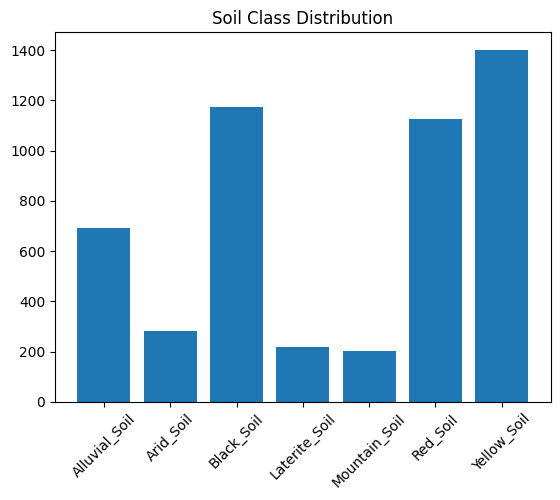

In [67]:
_, counts = np.unique(y, return_counts=True)
plt.bar(dirs, counts)
plt.xticks(rotation=45)
plt.title("Soil Class Distribution")
plt.show()

In [68]:
from collections import Counter

def augment_image(img):
    h, w = img.shape[0], img.shape[1]
    img_flat = img.reshape(h, w, 4)
    if np.random.rand() > 0.5:
        img_flat = np.fliplr(img_flat)
    if np.random.rand() > 0.5:
        img_flat = np.flipud(img_flat)
    factor = 1.0 + np.random.uniform(-0.1, 0.1)
    img_flat = np.clip(img_flat * factor, 0, 255)
    k = np.random.choice([0, 1, 2, 3])
    img_flat = np.rot90(img_flat, k=k)
    return img_flat.reshape(h, w, 2, 2)

def oversample_to_balance(X, y):
    class_counts = Counter(y)
    max_count = max(class_counts.values())
    X_out, y_out = list(X), list(y)
    for cls, count in class_counts.items():
        if count < max_count:
            cls_idx = np.where(y == cls)[0]
            for _ in range(max_count - count):
                aug = augment_image(X[np.random.choice(cls_idx)])
                X_out.append(aug)
                y_out.append(cls)
    X_out, y_out = np.array(X_out), np.array(y_out)
    perm = np.random.permutation(len(y_out))
    return X_out[perm], y_out[perm]

## Step 1 — Add Redundant 4th Band

Duplicate the **Red channel (index 0)** as a 4th band.

```
(N, 128, 128, 3)  →  (N, 128, 128, 4)
```

In [69]:
red_channel = X[:, :, :, 0:1]                          # (N, 128, 128, 1)
X_4band = np.concatenate([X, red_channel], axis=-1)    # (N, 128, 128, 4)

print("X_4band shape:", X_4band.shape)

X_4band shape: (5097, 64, 64, 4)


## Step 2 — Reshape Band Axis: flat (4,) → square (2, 2)

Instead of treating the 4 bands as a flat vector, we arrange them as a **2×2 matrix**.
This is a pure reshape — **no information is lost**.

```
Flat (4,):             2×2 matrix:
[ R, G, B, R* ]  →    ┌───┬────┐
                       │ R │ G  │
                       ├───┼────┤
                       │ B │ R* │
                       └───┴────┘

(N, 128, 128, 4)  →   (N, 128, 128, 2, 2)
```

In [70]:
N, H, W, C = X_4band.shape   # C == 4

# Key reshape: last axis 4 → (2, 2)
X_sq = X_4band.reshape(N, H, W, 2, 2)    # (N, 128, 128, 2, 2)

print("X_sq shape:", X_sq.shape)

# Sanity check — values must be identical to original
assert np.array_equal(X_sq[0, 0, 0].flatten(), X_4band[0, 0, 0]), "Reshape mismatch!"
print("Sanity check passed — reshape is lossless.")

# Show the 2x2 band matrix for one pixel
print("\nBand layout (2×2) for pixel (0,0) of image 0:")
print(X_sq[0, 0, 0])
print("Flat (original):", X_4band[0, 0, 0])

X_sq shape: (5097, 64, 64, 2, 2)
Sanity check passed — reshape is lossless.

Band layout (2×2) for pixel (0,0) of image 0:
[[132.  93.]
 [ 50. 132.]]
Flat (original): [132.  93.  50. 132.]


## Step 3 — Train / Val / Test Split

In [71]:
num_classes = len(dirs)
y_cat = to_categorical(y, num_classes=num_classes)

# Carve out test set from ORIGINAL data only (no augmented images in test)
X_trainval, X_test, y_trainval, y_test_raw = train_test_split(
    X_sq, y, test_size=0.15, stratify=y, random_state=42
)

# Oversample only train+val
X_trainval_bal, y_trainval_bal = oversample_to_balance(X_trainval, y_trainval)

# Split into train/val
y_tv_cat = to_categorical(y_trainval_bal, num_classes=num_classes)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval_bal, y_tv_cat, test_size=0.15,
    stratify=y_trainval_bal, random_state=42
)
y_test = to_categorical(y_test_raw, num_classes=num_classes)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (7086, 64, 64, 2, 2)
Val   : (1251, 64, 64, 2, 2)
Test  : (765, 64, 64, 2, 2)


In [72]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)

class_weights[0] *= 2
class_weights[1] *= 3
class_weights[3] *= 3
class_weights[4] *= 2
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.9985897616697221), 1: np.float64(2.9978846425045833), 2: np.float64(1.0002823263692828), 3: np.float64(3.0008469791078483), 4: np.float64(2.0005646527385657), 5: np.float64(1.0002823263692828), 6: np.float64(1.0002823263692828)}


## Step 4 — Model Architecture (Conv3D)

Input shape `(128, 128, 2, 2)` has **two spatial axes** (H, W) and **two band axes** (band_row, band_col).

**Conv3D** treats the tensor as a 3D volume: `(H, W, band_row)`, sliding a kernel across
all three axes simultaneously. This lets it learn **joint spatial-spectral patterns**.

```
Input  (128, 128, 2, 2)
  │
Conv3D(32,  kernel 3×3×2)  →  (128, 128, 1, 32)   # collapses band_row
MaxPool3D(2×2×1)           →  ( 64,  64, 1, 32)
  │
Conv3D(64,  kernel 3×3×1)  →  ( 64,  64, 1, 64)
MaxPool3D(2×2×1)           →  ( 32,  32, 1, 64)
  │
Conv3D(128, kernel 3×3×1)  →  ( 32,  32, 1, 128)
MaxPool3D(2×2×1)           →  ( 16,  16, 1, 128)
  │
Conv3D(256, kernel 3×3×1)
  │
GlobalAveragePooling3D     →  (256,)
  │
Dense(256) → Dense(7, softmax)
```

In [73]:
inputs = tf.keras.Input(shape=(H, W, 2, 2))   # (128, 128, 2, 2)

# Block 1 — kernel (3,3,2) collapses both band rows at once
x = Conv3D(32, kernel_size=(3, 3, 2), padding='same', activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling3D(pool_size=(2, 2, 1))(x)   # → (64, 64, 2, 32)
x = Dropout(0.1)(x)

# Block 2
x = Conv3D(64, kernel_size=(3, 3, 2), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling3D(pool_size=(2, 2, 1))(x)   # → (32, 32, 2, 64)
x = Dropout(0.15)(x)

# Block 3 — pool_size (2,2,2) collapses remaining band dim
x = Conv3D(128, kernel_size=(3, 3, 2), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling3D(pool_size=(2, 2, 2))(x)   # → (16, 16, 1, 128)
x = Dropout(0.2)(x)

# Block 4
x = Conv3D(256, kernel_size=(3, 3, 1), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

# Head
x = GlobalAveragePooling3D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 2, 2)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_16 (Conv3D)              │ (None, 64, 64, 2, 32)  │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 2, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_12 (MaxPooling3D) │ (None, 32, 32, 2, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32, 32, 2, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_17 (Conv3D)              │ (None, 32, 32, 2, 64)  │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 2, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_13 (MaxPooling3D) │ (None, 16, 16, 2, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16, 16, 2, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_18 (Conv3D)              │ (None, 16, 16, 2, 128) │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 2, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_14 (MaxPooling3D) │ (None, 8, 8, 1, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 8, 8, 1, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_19 (Conv3D)              │ (None, 8, 8, 1, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8, 8, 1, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 8, 8, 1, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,375 (2.10 MB)

 Trainable params: 549,415 (2.10 MB)

 Non-trainable params: 960 (3.75 KB)

In [77]:
class MacroF1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(shape=(num_classes,), initializer='zeros', name='tp') #true positive
        self.fp = self.add_weight(shape=(num_classes,), initializer='zeros', name='fp') #false positive
        self.fn = self.add_weight(shape=(num_classes,), initializer='zeros', name='fn') #false negative

    def update_state(self, y_true, y_pred, sample_weight=None):
        yp = tf.one_hot(tf.argmax(y_pred, axis=1), self.num_classes)  # (B, C)
        yt = tf.one_hot(tf.argmax(y_true, axis=1), self.num_classes)  # (B, C)

        # Sum over batch dimension → shape (C,)
        self.tp.assign_add(tf.reduce_sum(yp * yt,       axis=0))
        self.fp.assign_add(tf.reduce_sum(yp * (1 - yt), axis=0))
        self.fn.assign_add(tf.reduce_sum((1 - yp) * yt, axis=0))

    def result(self):
        p  = self.tp / (self.tp + self.fp + 1e-7)
        r  = self.tp / (self.tp + self.fn + 1e-7)
        return tf.reduce_mean(2 * p * r / (p + r + 1e-7))

    def reset_state(self):
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', MacroF1Score(num_classes)]
)

callbacks = [
    EarlyStopping(monitor='val_macro_f1', patience=8,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_macro_f1', patience=4, mode='max')
]

In [78]:
# callbacks = [
#     EarlyStopping(patience=8, restore_best_weights=True),
#     ReduceLROnPlateau(patience=4)
# ]

## Step 5 — Training with tf.data Pipeline

In [79]:
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(X, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    return ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 265ms/step - accuracy: 0.6956 - loss: 1.7152 - macro_f1: 0.6989 - val_accuracy: 0.5755 - val_loss: 1.8167 - val_macro_f1: 0.5282 - learning_rate: 0.0010
Epoch 2/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - accuracy: 0.8153 - loss: 1.0946 - macro_f1: 0.8175 - val_accuracy: 0.6811 - val_loss: 1.0334 - val_macro_f1: 0.6707 - learning_rate: 0.0010
Epoch 3/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - accuracy: 0.8481 - loss: 0.9133 - macro_f1: 0.8495 - val_accuracy: 0.7874 - val_loss: 0.5927 - val_macro_f1: 0.7876 - learning_rate: 0.0010
Epoch 4/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.8650 - loss: 0.8359 - macro_f1: 0.8659 - val_accuracy: 0.8058 - val_loss: 0.4876 - val_macro_f1: 0.8003 - learning_rate: 0.0010
Epoch 5/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.8633 - loss: 0.8082 - macro_f1: 0.8643 - val_accuracy: 0.7994 - val_loss: 0.5758 - val_macro_f1: 0.7974 - learning_rate: 0.0010
Epoch 6/40
111/

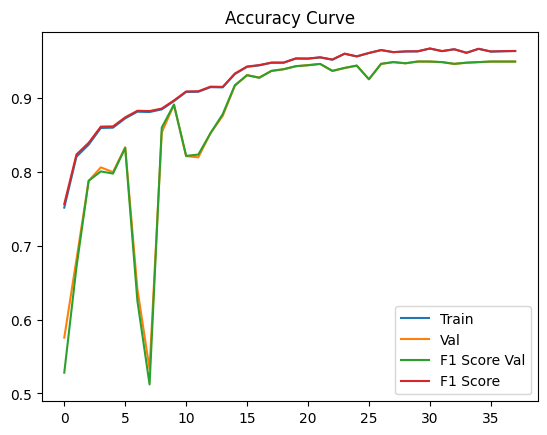

In [82]:
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.plot(history.history['val_macro_f1'],        label='F1 Score Val')
plt.plot(history.history['macro_f1'],        label='F1 Score')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [83]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9628 - loss: 0.1440 - macro_f1: 0.8988


[0.17166003584861755, 0.95686274766922, 0.9052527546882629]

In [86]:
# y_pred = model.predict(test_ds)

# f1 = f1_score(
#     np.argmax(y_test, axis=1),
#     np.argmax(y_pred, axis=1),
#     average='macro'
# )
# print("Macro F1:", round(f1, 4))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Macro F1: 0.1581


In [88]:
from collections import Counter

# Step 1 — collect predictions and labels directly from dataset
y_true_list, y_pred_list = [], []

for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    y_pred_list.append(preds)
    y_true_list.append(y_batch.numpy())

y_pred_all = np.argmax(np.concatenate(y_pred_list), axis=1)
y_true_all = np.argmax(np.concatenate(y_true_list), axis=1)

# Step 2 — check distributions
print("Predicted class distribution:", Counter(y_pred_all))
print("True class distribution:     ", Counter(y_true_all))

# Step 3 — check if model is just guessing one class
unique_preds = len(set(y_pred_all.tolist()))
print(f"\nModel is predicting {unique_preds} distinct classes out of {num_classes}")

# Step 4 — per class F1
from sklearn.metrics import classification_report
print("\n", classification_report(y_true_all, y_pred_all, target_names=dirs))

Predicted class distribution: Counter({np.int64(6): 207, np.int64(2): 176, np.int64(5): 164, np.int64(0): 108, np.int64(1): 49, np.int64(3): 36, np.int64(4): 25})
True class distribution:      Counter({np.int64(6): 210, np.int64(2): 176, np.int64(5): 169, np.int64(0): 104, np.int64(1): 43, np.int64(3): 33, np.int64(4): 30})

Model is predicting 7 distinct classes out of 7

                precision    recall  f1-score   support

Alluvial_Soil       0.92      0.95      0.93       104
    Arid_Soil       0.76      0.86      0.80        43
   Black_Soil       0.99      0.99      0.99       176
Laterite_Soil       0.72      0.79      0.75        33
Mountain_Soil       0.96      0.80      0.87        30
     Red_Soil       1.00      0.97      0.98       169
  Yellow_Soil       1.00      0.99      0.99       210

     accuracy                           0.96       765
    macro avg       0.91      0.91      0.91       765
 weighted avg       0.96      0.96      0.96       765



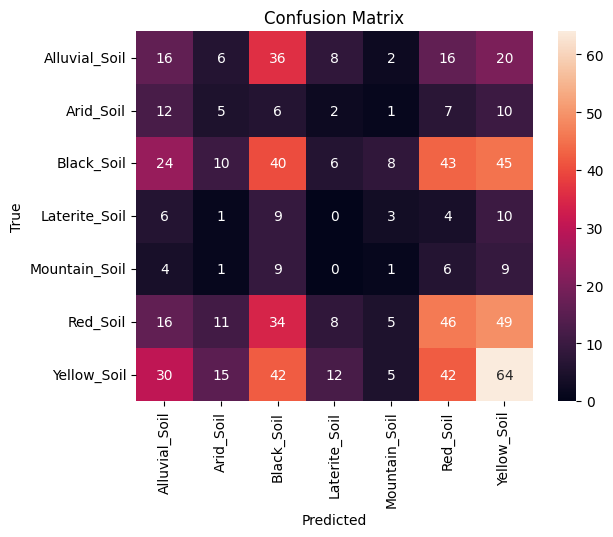

In [89]:
# cm = confusion_matrix(
#     np.argmax(y_test, axis=1),
#     np.argmax(y_pred, axis=1)
# )

# sns.heatmap(cm, annot=True, fmt='d', xticklabels=dirs, yticklabels=dirs)
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

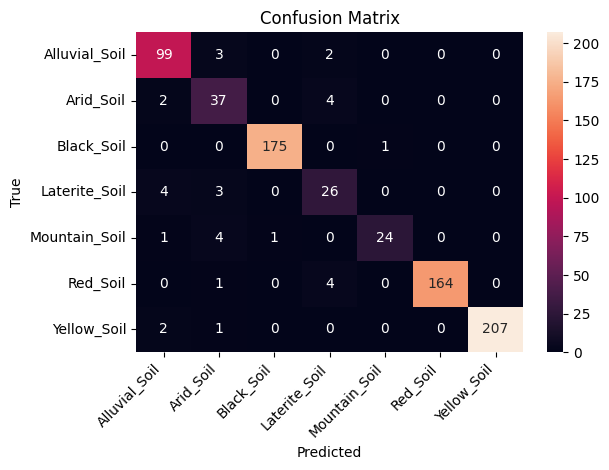

In [91]:
cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=dirs,
    yticklabels=dirs,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [92]:
model.save("best_soil_classifier_2x2bands.keras")